In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_path = "/content/drive/MyDrive/Flickr8k"
print(os.listdir(drive_path))

['captions.txt', 'Images']


In [ ]:
!cp -r /content/drive/MyDrive/Flickr8k /content/

In [ ]:
local_path = "/content/Flickr8k"
print(os.listdir(local_path))
print("Number of images:", len(os.listdir(local_path + "/Images")))

['Images', 'captions.txt']
Number of images: 8091


In [ ]:
captions_file = "/content/Flickr8k/captions.txt"

with open(captions_file, 'r') as f:
    lines = f.readlines()

print("Total lines:", len(lines))
print("First 5 lines:\n", lines[:5])

Total lines: 40456
First 5 lines:
 ['image,caption\n', '1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .\n', '1000268201_693b08cb0e.jpg,A girl going into a wooden building .\n', '1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .\n', '1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .\n']


In [ ]:
from collections import defaultdict

captions_dict = defaultdict(list)

for line in lines[1:]:
    line = line.strip()
    if len(line) == 0:
        continue

    image, caption = line.split(',', 1)
    captions_dict[image].append(caption.lower())

print("Total unique images:", len(captions_dict))

Total unique images: 8091


In [ ]:
example_image = list(captions_dict.keys())[0]
print("Image:", example_image)
print("Captions:")
for cap in captions_dict[example_image]:
    print("-", cap)

Image: 1000268201_693b08cb0e.jpg
Captions:
- a child in a pink dress is climbing up a set of stairs in an entry way .
- a girl going into a wooden building .
- a little girl climbing into a wooden playhouse .
- a little girl climbing the stairs to her playhouse .
- a little girl in a pink dress going into a wooden cabin .


In [ ]:
import string
import re

def clean_caption(caption):
    caption = caption.translate(str.maketrans('', '', string.punctuation))

    caption = re.sub(r'\d+', '', caption)

    caption = caption.strip()

    caption = ' '.join([word for word in caption.split() if len(word) > 1 or word == 'a'])

    return caption

In [ ]:
cleaned_captions = {}

for image, caps in captions_dict.items():
    cleaned_captions[image] = []

    for cap in caps:
        clean_cap = clean_caption(cap)
        clean_cap = "<start> " + clean_cap + " <end>"
        cleaned_captions[image].append(clean_cap)

In [ ]:
example_image = list(cleaned_captions.keys())[0]

print("Image:", example_image)
print("Cleaned Captions:")
for cap in cleaned_captions[example_image]:
    print("-", cap)

Image: 1000268201_693b08cb0e.jpg
Cleaned Captions:
- <start> a child in a pink dress is climbing up a set of stairs in an entry way <end>
- <start> a girl going into a wooden building <end>
- <start> a little girl climbing into a wooden playhouse <end>
- <start> a little girl climbing the stairs to her playhouse <end>
- <start> a little girl in a pink dress going into a wooden cabin <end>


In [ ]:
from collections import Counter

all_captions = []

for caps in cleaned_captions.values():
    all_captions.extend(caps)

print("Total captions:", len(all_captions))

Total captions: 40455


In [ ]:
word_counts = Counter()

for caption in all_captions:
    words = caption.split()
    word_counts.update(words)

print("Total unique words:", len(word_counts))

Total unique words: 8768


In [ ]:
min_freq = 5

vocab = [word for word, count in word_counts.items() if count >= min_freq]

print("Vocabulary size after filtering:", len(vocab))

Vocabulary size after filtering: 2984


In [ ]:
special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
vocab = special_tokens + vocab

In [ ]:
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print("Final vocabulary size:", len(word2idx))

Final vocabulary size: 2986


In [ ]:
print("Index of <start>:", word2idx['<start>'])
print("Index of <end>:", word2idx['<end>'])
print("Index of <pad>:", word2idx['<pad>'])

Index of <start>: 4
Index of <end>: 18
Index of <pad>: 0


In [ ]:
max_length = 0
caption_sequences = {}

for image, caps in cleaned_captions.items():
    caption_sequences[image] = []

    for cap in caps:
        seq = []
        for word in cap.split():
            if word in word2idx:
              seq.append(word2idx[word])
            else:
              seq.append(word2idx['<unk>'])

        caption_sequences[image].append(seq)

        if len(seq) > max_length:
            max_length = len(seq)

print("Maximum caption length:", max_length)

Maximum caption length: 37


In [ ]:
import numpy as np

for image, caps in caption_sequences.items():
    for i in range(len(caps)):
        seq = caps[i]

        if len(seq) < max_length:
            seq = seq + [word2idx['<pad>']] * (max_length - len(seq))

        caption_sequences[image][i] = seq

In [ ]:
example_image = list(caption_sequences.keys())[0]

print("Padded sequence example:")
print(caption_sequences[example_image][0])
print("Length:", len(caption_sequences[example_image][0]))

Padded sequence example:
[4, 5, 6, 7, 5, 8, 9, 10, 11, 12, 5, 13, 14, 15, 7, 16, 3, 17, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 37


In [ ]:
from sklearn.model_selection import train_test_split

all_images = list(caption_sequences.keys())

train_images, val_images = train_test_split(
    all_images,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))

Training images: 6472
Validation images: 1619


In [ ]:
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os
import random

class FlickrDataset(Dataset):
    def __init__(self, image_list, captions_dict, image_folder, transform):
        self.image_list = image_list
        self.captions_dict = captions_dict
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_name = self.image_list[idx]
        image_path = os.path.join(self.image_folder, image_name)


        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)


        caption = random.choice(self.captions_dict[image_name])
        caption = torch.tensor(caption)


        caption_length = (caption != word2idx['<pad>']).sum()

        return image, caption, caption_length

In [ ]:
image_folder = "/content/Flickr8k/Images"

train_dataset = FlickrDataset(
    train_images,
    caption_sequences,
    image_folder,
    transform
)

val_dataset = FlickrDataset(
    val_images,
    caption_sequences,
    image_folder,
    transform
)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
images, captions, lengths = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Caption batch shape:", captions.shape)
print("Caption lengths:", lengths)

Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 37])
Caption lengths: tensor([17, 15, 17,  9, 15, 12, 18, 10,  9, 20, 12, 11, 12, 12,  9, 14, 19, 18,
        13, 14, 14, 14, 13, 10, 15, 15, 11, 13, 11,  8,  9, 23])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
resnet = efficientnet_b0(weights=weights)

In [ ]:
modules = list(resnet.children())[:-2]
resnet_encoder = nn.Sequential(*modules)

In [ ]:
for param in resnet_encoder.parameters():
    param.requires_grad = False

for param in list(resnet_encoder.parameters())[-40:]:
    param.requires_grad = True

In [ ]:
sample_images, sample_captions, sample_lengths = next(iter(train_loader))

with torch.no_grad():
    features = resnet_encoder(sample_images)

print("Feature shape:", features.shape)

Feature shape: torch.Size([32, 1280, 7, 7])


In [ ]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()

        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):

        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)

        att = self.full_att(self.relu(att1 + att2)).squeeze(2)

        alpha = self.softmax(att)

        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)

        return context, alpha

In [ ]:
sample_images, sample_captions, sample_lengths = next(iter(train_loader))

with torch.no_grad():
    features = resnet_encoder(sample_images)

batch_size = features.size(0)
encoder_dim = features.size(1)

features = features.view(batch_size, encoder_dim, -1)
features = features.permute(0, 2, 1)

print("Reshaped features:", features.shape)

Reshaped features: torch.Size([32, 49, 1280])


In [ ]:
attention = Attention(
  encoder_dim=1280,
  decoder_dim=1024,
  attention_dim=256
)
dummy_hidden = torch.randn(batch_size, 1024)
context, alpha = attention(features, dummy_hidden)
print("Context shape:", context.shape)
print("Alpha shape:", alpha.shape)

Context shape: torch.Size([32, 1280])
Alpha shape: torch.Size([32, 49])


In [ ]:
class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderWithAttention, self).__init__()

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)

        self.fc = nn.Linear(decoder_dim, vocab_size)

        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        self.relu = nn.ReLU()

    def init_hidden_state(self, encoder_out):
        mean_encoder = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder)
        c = self.init_c(mean_encoder)
        return h, c

    def forward(self, encoder_out, captions, lengths):

      batch_size = encoder_out.size(0)
      vocab_size = self.fc.out_features
      max_length = max(lengths)

      h, c = self.init_hidden_state(encoder_out)

      embeddings = self.dropout(self.embedding(captions))

      outputs = torch.zeros(batch_size, max_length, vocab_size).to(captions.device)

      for t in range(max_length):

        batch_size_t = sum([l > t for l in lengths])

        context, alpha = self.attention(
            encoder_out[:batch_size_t],
            h[:batch_size_t]
        )

        lstm_input = torch.cat(
            [embeddings[:batch_size_t, t, :], context],
            dim=1
        )

        h_t, c_t = self.lstm(
            lstm_input,
            (h[:batch_size_t], c[:batch_size_t])
        )

        preds = self.fc(self.dropout(h_t))

        outputs[:batch_size_t, t, :] = preds

        h = torch.cat([h_t, h[batch_size_t:]], dim=0)
        c = torch.cat([c_t, c[batch_size_t:]], dim=0)

      return outputs

In [ ]:
vocab_size = len(word2idx)

attention_dim = 256
embed_dim = 512
decoder_dim = 1024

decoder = DecoderWithAttention(
    attention_dim=attention_dim,
    embed_dim=embed_dim,
    decoder_dim=decoder_dim,
    vocab_size=vocab_size,
    encoder_dim=encoder_dim
)

In [ ]:
sample_images, sample_captions, sample_lengths = next(iter(train_loader))

with torch.no_grad():
    features = resnet_encoder(sample_images)

batch_size = features.size(0)
encoder_dim = features.size(1)

features = features.view(batch_size, encoder_dim, -1)
features = features.permute(0, 2, 1)

outputs = decoder(features, sample_captions, sample_lengths)

print("Decoder output shape:", outputs.shape)

Decoder output shape: torch.Size([32, 24, 2986])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_encoder = resnet_encoder.to(device)
decoder = decoder.to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
criterion = nn.CrossEntropyLoss(
    ignore_index=word2idx['<pad>'],
    label_smoothing=0.1
)

In [ ]:
optimizer = torch.optim.Adam([
    {'params': decoder.parameters(), 'lr': 5e-4},
    {'params': resnet_encoder.parameters(), 'lr': 1e-5}
])

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [ ]:
num_epochs = 35
clip_value = 1

for epoch in range(num_epochs):

    decoder.train()
    resnet_encoder.eval()
    total_loss = 0

    for images, captions, lengths in train_loader:
        images = images.to(device)
        lengths = lengths.to(device)

        captions = captions.clamp(0, len(word2idx)-1).to(device)

        optimizer.zero_grad()


        features = resnet_encoder(images)
        batch_size = features.size(0)
        encoder_dim = features.size(1)
        features = features.view(batch_size, encoder_dim, -1)
        features = features.permute(0, 2, 1)


        input_lengths = (captions[:, :-1] != word2idx['<pad>']).sum(dim=1)


        outputs = decoder(
            features,
            captions[:, :-1],
            input_lengths
        )


        from torch.nn.utils.rnn import pack_padded_sequence
        targets = captions[:, 1:]
        packed_targets = pack_padded_sequence(
            targets, input_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs = pack_padded_sequence(
            outputs, input_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        loss = criterion(packed_outputs.data, packed_targets.data)


        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), clip_value)
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
    scheduler.step(epoch_loss)

Epoch [1/35], Loss: 5.5415
Epoch [2/35], Loss: 4.8725
Epoch [3/35], Loss: 4.6432
Epoch [4/35], Loss: 4.5023
Epoch [5/35], Loss: 4.4235
Epoch [6/35], Loss: 4.3504
Epoch [7/35], Loss: 4.2830
Epoch [8/35], Loss: 4.2150
Epoch [9/35], Loss: 4.1698
Epoch [10/35], Loss: 4.1228
Epoch [11/35], Loss: 4.0837
Epoch [12/35], Loss: 4.0264
Epoch [13/35], Loss: 4.0126
Epoch [14/35], Loss: 3.9615
Epoch [15/35], Loss: 3.9207
Epoch [16/35], Loss: 3.9029
Epoch [17/35], Loss: 3.8643
Epoch [18/35], Loss: 3.8129
Epoch [19/35], Loss: 3.8212
Epoch [20/35], Loss: 3.7770
Epoch [21/35], Loss: 3.7493
Epoch [22/35], Loss: 3.7281
Epoch [23/35], Loss: 3.7035
Epoch [24/35], Loss: 3.6862
Epoch [25/35], Loss: 3.6384
Epoch [26/35], Loss: 3.6319
Epoch [27/35], Loss: 3.6189
Epoch [28/35], Loss: 3.5972
Epoch [29/35], Loss: 3.5803
Epoch [30/35], Loss: 3.5444
Epoch [31/35], Loss: 3.5401
Epoch [32/35], Loss: 3.5231
Epoch [33/35], Loss: 3.5272
Epoch [34/35], Loss: 3.5001
Epoch [35/35], Loss: 3.4863


In [ ]:
save_path = "/content/drive/MyDrive/image_caption_model.pth"

torch.save({
    'encoder_state_dict': resnet_encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'word2idx': word2idx,
    'idx2word': idx2word,
    'attention_dim': attention_dim,
    'embed_dim': embed_dim,
    'decoder_dim': decoder_dim,
    'encoder_dim': encoder_dim,
    'epoch': num_epochs
}, save_path)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
def generate_caption_beam(image, beam_size=7, max_length=36):

    decoder.eval()
    resnet_encoder.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        features = resnet_encoder(image)

    batch_size = features.size(0)
    encoder_dim = features.size(1)


    features = features.view(batch_size, encoder_dim, -1)
    features = features.permute(0, 2, 1)


    h, c = decoder.init_hidden_state(features)


    start_token = word2idx['<start>']


    sequences = [[ [start_token], 0.0, h, c ]]
    completed_sequences = []

    for _ in range(max_length):
        all_candidates = []
        for seq, score, h, c in sequences:


            if seq[-1] == word2idx['<end>']:
                completed_sequences.append((seq, score))
                continue


            word = torch.tensor([seq[-1]]).to(device)
            embedding = decoder.embedding(word)


            context, alpha = decoder.attention(features, h)


            lstm_input = torch.cat([embedding.squeeze(1), context], dim=1)
            h_new, c_new = decoder.lstm(lstm_input, (h, c))


            output = decoder.fc(h_new)
            log_probs = torch.log_softmax(output, dim=1)


            top_log_probs, top_indices = torch.topk(log_probs, beam_size)

            for i in range(beam_size):
                next_word = top_indices[0][i].item()
                next_score = score + top_log_probs[0][i].item()
                candidate = [seq + [next_word], next_score, h_new, c_new]
                all_candidates.append(candidate)


        sequences = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)
        sequences = sequences[:beam_size]


        if len(completed_sequences) >= beam_size:
            break


    if len(completed_sequences) == 0:
        completed_sequences = sequences


    best_seq = sorted(completed_sequences, key=lambda tup: tup[1], reverse=True)[0][0]


    caption = [idx2word[idx] for idx in best_seq if idx2word[idx] not in ('<start>', '<end>')]

    return caption

Generated: a boy in a swimming pool


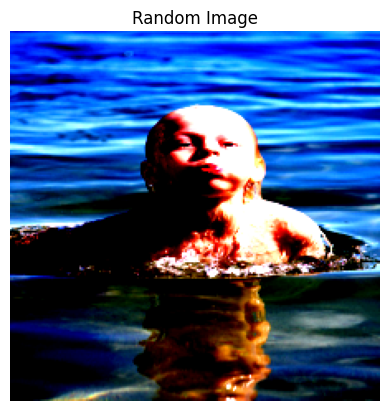

In [ ]:
import random

idx = random.randint(0, len(val_dataset)-1)
sample_img, sample_cap, _ = val_dataset[idx]
image_name = val_images[idx]

import matplotlib.pyplot as plt

img = sample_img.permute(1,2,0).cpu().numpy()
plt.imshow(img)
plt.title("Random Image")
plt.axis('off')

generated_caption = generate_caption_beam(sample_img, beam_size=5)

print("Generated:", " ".join(generated_caption))

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

references = []
hypotheses = []

for i in range(200):


    image, _, _ = val_dataset[i]


    image_name = val_images[i]
    gt_caps = cleaned_captions[image_name]


    gt_tokens = [cap.split()[1:-1] for cap in gt_caps]


    generated = generate_caption_beam(image, beam_size=3)

    references.append(gt_tokens)
    hypotheses.append(generated)

bleu_score = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25))

print("BLEU Score:", bleu_score)

BLEU Score: 0.20655109492488474


In [ ]:
!pip install transformers sentencepiece

In [ ]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "facebook/nllb-200-distilled-600M"


nllb_tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=False,
    src_lang="eng_Latn"
)

nllb_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [ ]:
print(type(nllb_tokenizer))

<class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>


In [ ]:
lang_code_map = {
    "hin_Deva": nllb_tokenizer.convert_tokens_to_ids("hin_Deva"),
    "mar_Deva": nllb_tokenizer.convert_tokens_to_ids("mar_Deva"),
}

In [ ]:
def translate_hindi(text):
    inputs = nllb_tokenizer(
        text,
        return_tensors="pt",
        src_lang="eng_Latn"
    ).to(device)

    with torch.no_grad():
        output = nllb_model.generate(
            **inputs,
            forced_bos_token_id=nllb_tokenizer.convert_tokens_to_ids("hin_Deva"),
            max_length=100,
            num_beams=5
        )

    return nllb_tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
def translate_marathi(text):
    inputs = nllb_tokenizer(
        text,
        return_tensors="pt",
        src_lang="eng_Latn"
    ).to(device)

    with torch.no_grad():
        output = nllb_model.generate(
            **inputs,
            forced_bos_token_id=nllb_tokenizer.convert_tokens_to_ids("mar_Deva"),
            max_length=100,
            num_beams=5
        )

    return nllb_tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

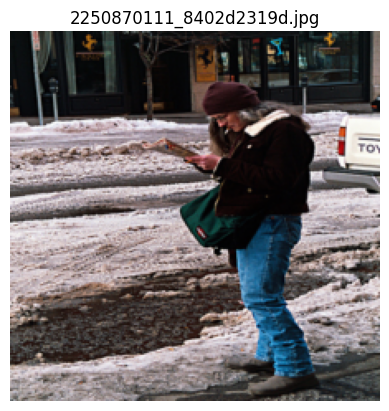


Image   : 2250870111_8402d2319d.jpg
English : a girl in a blue jacket stands in front of a building
Hindi   : नीली जैकेट में एक लड़की एक इमारत के सामने खड़ी है
Marathi : ब्लू जॅकेटमध्ये एक मुलगी इमारतीच्या समोर उभी आहे


In [ ]:

idx = random.randint(0, len(val_dataset)-1)
img, _, _ = val_dataset[idx]
name = val_images[idx]


plt.imshow(denormalize(img))
plt.title(name)
plt.axis('off')
plt.show()


caption = generate_caption_beam(img, beam_size=7)
english_caption = " ".join(caption)


hindi_caption = translate_hindi(english_caption)
marathi_caption = translate_marathi(english_caption)


print("\nImage   :", name)
print("English :", english_caption)
print("Hindi   :", hindi_caption)
print("Marathi :", marathi_caption)

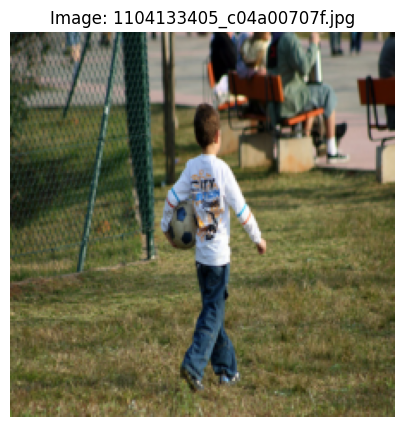


Image 1: 1104133405_c04a00707f.jpg
English : a little girl in a white shirt and blue jeans is walking on the grass
Hindi   : सफेद शर्ट और नीले जींस में एक छोटी लड़की घास पर चल रही है
Marathi : एक लहान मुलगी पांढरा शर्ट आणि ब्लू जीन्स घालून गवतवर फिरत आहे

------------------------------------------------------------



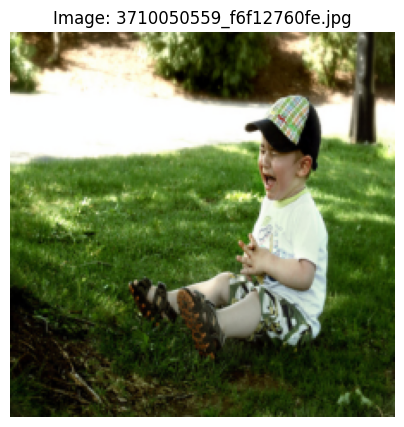


Image 2: 3710050559_f6f12760fe.jpg
English : a little boy is sitting on the grass next to a tree
Hindi   : एक छोटा लड़का एक पेड़ के बगल में घास पर बैठा है
Marathi : एक लहान मुलगा झाडाच्या शेजारी गवतावर बसला आहे.

------------------------------------------------------------



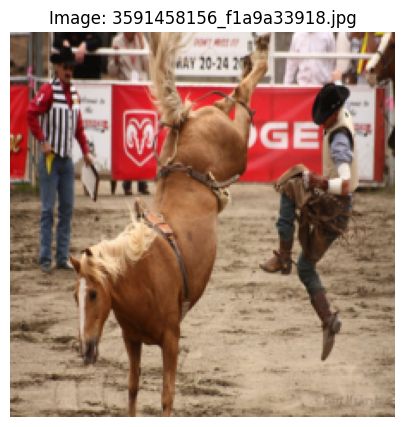


Image 3: 3591458156_f1a9a33918.jpg
English : a brown horse is being <unk> by a brown horse
Hindi   : एक भूरे रंग का घोड़ा एक भूरे रंग के घोड़े द्वारा पकड़ा जा रहा है।
Marathi : एक तपकिरी घोडा तपकिरी घोड्याने पकडला जात आहे.

------------------------------------------------------------



In [ ]:
num_samples = 3

for i in range(num_samples):


    idx = random.randint(0, len(val_dataset) - 1)
    img, _, _ = val_dataset[idx]
    name = val_images[idx]

    plt.figure(figsize=(5,5))
    plt.imshow(denormalize(img))
    plt.title(f"Image: {name}")
    plt.axis('off')
    plt.show()

    caption = generate_caption_beam(img, beam_size=7)
    english_caption = " ".join(caption)

    hindi_caption = translate_hindi(english_caption)
    marathi_caption = translate_marathi(english_caption)

    print(f"\nImage {i+1}: {name}")
    print("English :", english_caption)
    print("Hindi   :", hindi_caption)
    print("Marathi :", marathi_caption)

    print("\n" + "-"*60 + "\n")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-03-31 182831.png to Screenshot 2026-03-31 182831.png


In [ ]:
from PIL import Image

img_name = list(uploaded.keys())[0]

image = Image.open(img_name).convert("RGB")

In [ ]:
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
img_tensor = transform(image)

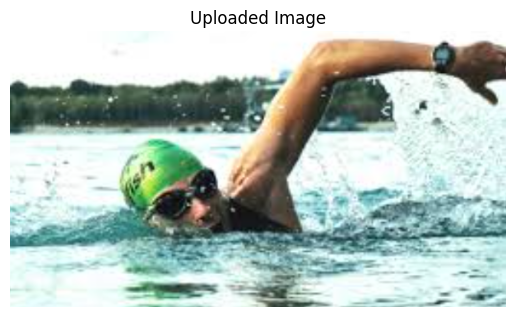


English : a man in a green hat is swimming in the water
Hindi   : हरे रंग की टोपी में एक आदमी पानी में तैर रहा है।
Marathi : ग्रीन हॅट असलेला माणूस पाण्यात पोहतो आहे.


In [ ]:
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

caption = generate_caption_beam(img_tensor, beam_size=7)
english_caption = " ".join(caption)

hindi_caption = translate_hindi(english_caption)
marathi_caption = translate_marathi(english_caption)

print("\nEnglish :", english_caption)
print("Hindi   :", hindi_caption)
print("Marathi :", marathi_caption)

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

bleu_scores = []

for i in range(100):
    image, _, _ = val_dataset[i]
    image_name = val_images[i]

    gt_caps = cleaned_captions[image_name]
    gt_tokens = [cap.split()[1:-1] for cap in gt_caps]

    pred = generate_caption_beam(image, beam_size=5)

    score = corpus_bleu([gt_tokens], [pred])
    bleu_scores.append(score)

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

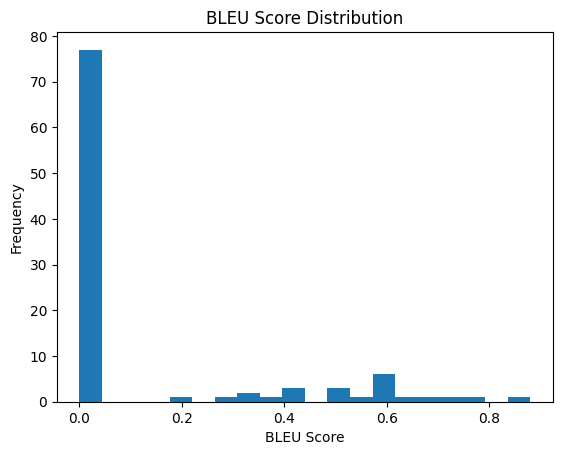

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(bleu_scores, bins=20)
plt.xlabel("BLEU Score")
plt.ylabel("Frequency")
plt.title("BLEU Score Distribution")
plt.show()

In [ ]:
caption_lengths = []

for caps in cleaned_captions.values():
    for cap in caps:
        caption_lengths.append(len(cap.split()))

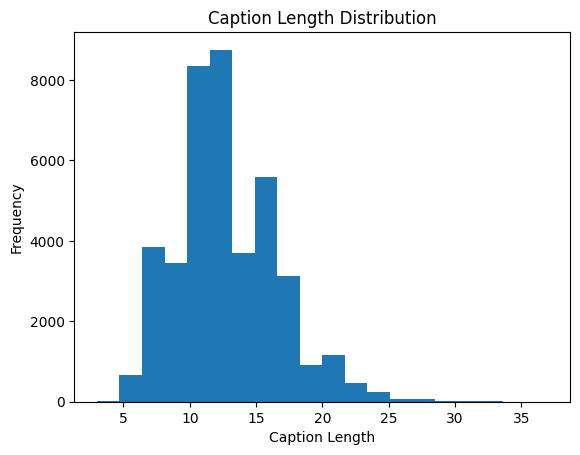

In [ ]:
plt.figure()
plt.hist(caption_lengths, bins=20)
plt.xlabel("Caption Length")
plt.ylabel("Frequency")
plt.title("Caption Length Distribution")
plt.show()

In [ ]:
gt_lengths = []
pred_lengths = []

for i in range(100):
    image, _, _ = val_dataset[i]
    image_name = val_images[i]

    gt_caps = cleaned_captions[image_name]
    gt_len = len(gt_caps[0].split())

    pred = generate_caption_beam(image, beam_size=5)
    pred_len = len(pred)

    gt_lengths.append(gt_len)
    pred_lengths.append(pred_len)

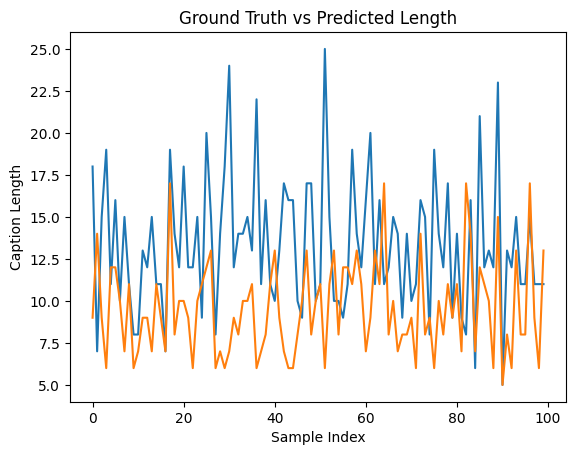

In [ ]:
plt.figure()
plt.plot(gt_lengths)
plt.plot(pred_lengths)
plt.xlabel("Sample Index")
plt.ylabel("Caption Length")
plt.title("Ground Truth vs Predicted Length")
plt.show()

In [ ]:
import time

times = []

for i in range(20):
    image, _, _ = val_dataset[i]

    start = time.time()
    _ = generate_caption_beam(image, beam_size=5)
    times.append(time.time() - start)

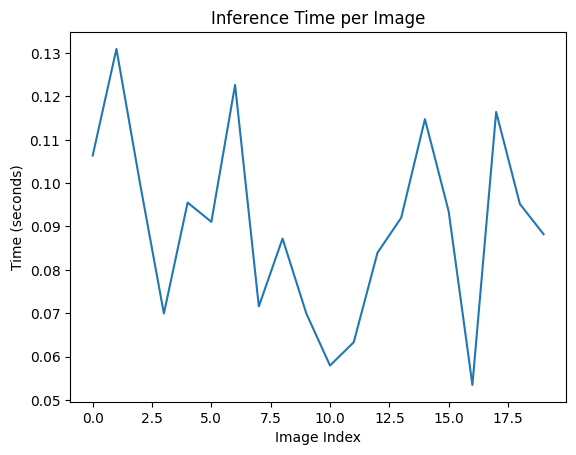

In [ ]:
plt.figure()
plt.plot(times)
plt.xlabel("Image Index")
plt.ylabel("Time (seconds)")
plt.title("Inference Time per Image")
plt.show()

In [ ]:
from collections import Counter

word_freq = Counter()

for caps in cleaned_captions.values():
    for cap in caps:
        word_freq.update(cap.split())

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

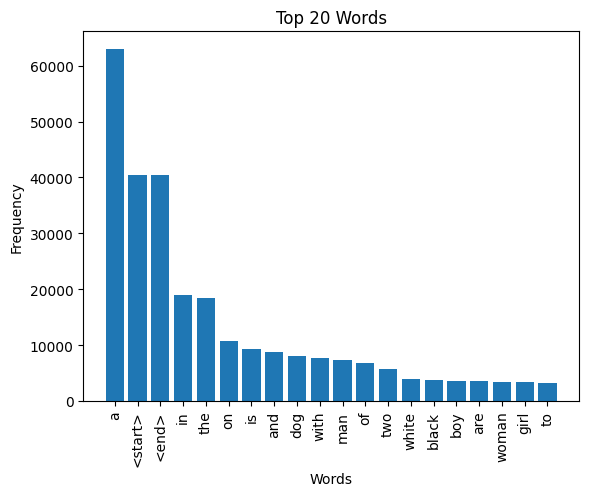

In [ ]:
plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Words")
plt.show()

In [ ]:
eng_len = []
hin_len = []
mar_len = []

for i in range(50):
    image, _, _ = val_dataset[i]

    pred = generate_caption_beam(image, beam_size=5)
    eng = " ".join(pred)

    hin = translate_hindi(eng)
    mar = translate_marathi(eng)

    eng_len.append(len(eng.split()))
    hin_len.append(len(hin.split()))
    mar_len.append(len(mar.split()))

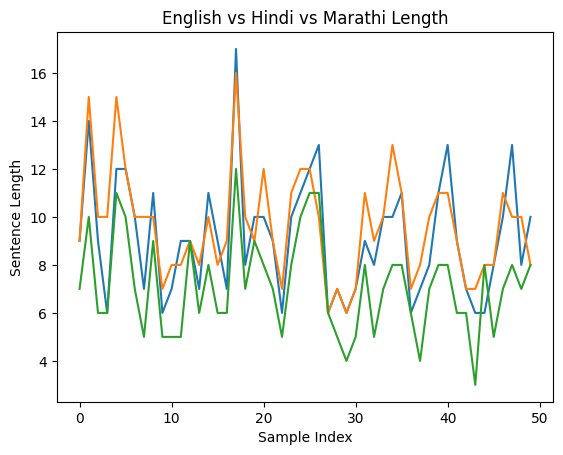

In [ ]:
plt.figure()
plt.plot(eng_len)
plt.plot(hin_len)
plt.plot(mar_len)
plt.xlabel("Sample Index")
plt.ylabel("Sentence Length")
plt.title("English vs Hindi vs Marathi Length")
plt.show()